In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from libs.prism_lib import PRISM
from libs.prism_program_lib import *
from libs.prism_diagnostics_helpers import *

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=PSI_ID, verbose=verbose)

prism.root_prism, prism.root_prism.exists()
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: TCGA
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_tcga_pan_can_atlas_2018
>> gdc_project_id: TCGA-PAAD

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/TCGA/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/TCGA/PAAD/mutations
-----------------------------

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [6]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [7]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [8]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [9]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### BayesPrism

In [10]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism'), True)

### Running prism

In [11]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (7.6 MB)
1918


In [12]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [13]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

In [14]:
df_theta = res.theta
print(df_theta.shape)
df_theta.head(5)

(134, 10)


,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.610,8.766e-03,0.025,0.029,8.930e-73,0.018,0.095,1.190e-152,1.096e-01,0.105
T-C3L-03635,0.773,5.554e-03,0.016,0.028,3.031e-163,0.009,0.168,4.220e-105,2.212e-72,0.000
T-C3L-02701,0.777,1.298e-08,0.028,0.016,1.993e-222,0.005,0.160,1.440e-02,1.715e-148,0.000
T-C3L-04072,0.311,1.755e-02,0.080,0.036,1.500e-144,0.038,0.489,0.000e+00,2.825e-02,0.001
T-C3L-00589,0.399,4.509e-02,0.049,0.037,2.831e-125,0.015,0.400,1.222e-296,1.538e-02,0.039


In [15]:
df_theta.tail(5)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-07033,0.011,0.004,8.328e-80,0.005,5.286e-179,3.171e-04,2.879e-03,2.122e-161,0.016,0.960
N-C3L-00819,0.356,0.031,4.032e-02,0.044,3.410e-131,6.492e-03,3.020e-02,7.387e-02,0.122,0.297
N-C3N-00517,0.074,0.005,8.473e-03,0.008,6.610e-61,2.818e-03,2.666e-07,3.797e-154,0.025,0.877
N-C3L-07037,0.043,0.023,1.956e-49,0.017,1.032e-142,3.970e-04,1.159e-02,0.000e+00,0.061,0.844
N-TCGA-H6-8124,0.594,0.015,9.105e-02,0.031,4.901e-138,4.365e-16,7.413e-02,4.034e-03,0.156,0.035


### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. 

If both had been mapped to malignant, purity would inflate. 

Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


In [16]:
res.tumor_purity

T-C3L-02890       9.479e-02
T-C3L-03635       1.682e-01
T-C3L-02701       1.602e-01
T-C3L-04072       4.891e-01
T-C3L-00589       4.001e-01
                    ...    
N-C3L-07033       2.879e-03
N-C3L-00819       3.020e-02
N-C3N-00517       2.666e-07
N-C3L-07037       1.159e-02
N-TCGA-H6-8124    7.413e-02
Name: tumor_purity, Length: 134, dtype: float64

In [20]:
tumor_samples = [s for s in res.tumor_purity.index if s.startswith("T-")]

res.tumor_purity.loc[tumor_samples].describe()

count    1.270e+02
mean     3.170e-01
std      2.342e-01
min      1.283e-22
25%      1.256e-01
50%      2.755e-01
75%      4.544e-01
max      9.559e-01
Name: tumor_purity, dtype: float64

### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [21]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 134)

In [22]:
res.cell_type_expression("Ductal cell type 1").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000938,51.218,NaN,NaN,36.618,70.526,125.742,NaN,101.382,64.265,NaN,...,NaN,101.952,13.168,75.530,30.534,15.616,73.528,45.118,38.236,80.840
ENSG00000001617,47.500,NaN,NaN,140.915,37.864,112.743,NaN,48.435,100.758,NaN,...,NaN,96.281,74.532,52.604,25.728,35.796,47.956,47.744,34.831,87.092
ENSG00000001626,98190.695,NaN,NaN,59536.148,63445.254,12140.707,NaN,84587.891,92432.820,NaN,...,NaN,49827.895,30.992,84145.344,64319.625,59948.570,86459.445,62941.730,37286.605,76825.766


In [23]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 134)

In [24]:
res.cell_type_expression("Ductal cell type 2").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000938,101.238,47.079,160.446,72.654,124.601,231.490,120.226,179.039,105.611,123.784,...,308.256,184.530,22.905,135.446,44.785,21.671,168.955,39.213,64.551,191.390
ENSG00000001617,205.817,182.625,274.975,612.905,146.645,455.000,435.186,187.507,362.987,243.437,...,368.939,382.020,284.192,206.794,82.722,108.899,241.567,90.964,128.905,452.002
ENSG00000001626,4418.257,1466.106,827.773,2689.088,2551.714,508.811,1419.792,3400.623,3458.009,1034.301,...,640.285,2053.082,1.227,3435.089,2147.555,1893.872,4522.679,1245.314,1432.995,4140.573


### 2. theta is now fixed -> expand Z to every gene

In [25]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

verbose=True
force=False

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        force=force, verbose=verbose)

force=False
verbose=True
fname = "count-matrix.txt"
fname_ad = fname.replace('.txt', '.h5ad')

adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

filename_ad = prism.root_prism / fname_ad
compression = "gzip"

verbose=True
fname_celltype = "all_celltype.txt"
adata = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

ref, s2t = prism.pseudobulk_reference(adata)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file
Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype

In [26]:
df_meta

,condition,program,dataset,condition_numeric
cols,,,,
T-C3L-02890,tumor,CPTAC3,PAAD,1.0
T-C3L-03635,tumor,CPTAC3,PAAD,1.0
T-C3L-02701,tumor,CPTAC3,PAAD,1.0
T-C3L-04072,tumor,CPTAC3,PAAD,1.0
T-C3L-00589,tumor,CPTAC3,PAAD,1.0
...,...,...,...,...
N-C3L-02606,normal,CPTAC3,PAAD,0.0
N-C3N-03173,normal,CPTAC3,PAAD,0.0
N-C3N-02696,normal,CPTAC3,PAAD,0.0


In [27]:
df_metadata = cbio.open_metadata()
df_metadata

,condition,program,dataset,condition_numeric
cols,,,,
T-C3L-02890,tumor,CPTAC3,PAAD,1.0
T-C3L-03635,tumor,CPTAC3,PAAD,1.0
T-C3L-02701,tumor,CPTAC3,PAAD,1.0
T-C3L-04072,tumor,CPTAC3,PAAD,1.0
T-C3L-00589,tumor,CPTAC3,PAAD,1.0
...,...,...,...,...
N-C3L-02606,normal,CPTAC3,PAAD,0.0
N-C3N-03173,normal,CPTAC3,PAAD,0.0
N-C3N-02696,normal,CPTAC3,PAAD,0.0


### Bulk - by geneid

In [28]:
force=False
verbose=True

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=force, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [29]:
def fix_good_cols(res, df_bulk, df_meta):
    cols_good = res.theta.index.to_list()
    df_bulk = df_bulk[cols_good]
    df_meta = df_meta.loc[cols_good]

    return df_bulk, df_meta

df_bulk, df_meta = fix_good_cols(res, df_bulk, df_meta)
df_bulk.shape, df_meta.shape

((27177, 134), (134, 4))

In [30]:
df_bulk.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,659,1294,395,1633,1079,1275,1315,1695,1261,3738
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,3,3,0,0,9,0,106,2,2,4
ENSG00000000419,1330,1521,1499,986,1388,974,649,1171,1120,1428,...,839,717,1034,1281,655,1087,931,1075,1059,1532


### List bulks by symobl

In [31]:
#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
bulk_symbs = gene_map.loc[df_bulk.index.to_list()].symbol.to_list()
len(bulk_symbs), bulk_symbs[:5]

(27177, ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112'])

### ref_new --> new reference, by geneid (ensbeml)

In [32]:
# prism.open_new_reference(verbose=verbose)

In [33]:
verbose=True

ref_new, df_to_from = prism.open_new_reference(verbose=verbose)
ref = ref_new

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

Table opened ((10, 17540)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/ref_new_geneid.tsv'
Table opened ((23789, 5)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/to_from_table.tsv'
(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### ref_new, s2t

In [34]:
print(ref_new.shape)
ref_new.head(3)

(10, 17540)


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
print(type(s2t), len(s2t))
s2t

<class 'pandas.core.series.Series'> 10


cell_state
Fibroblast cell          Fibroblast cell
Stellate cell              Stellate cell
Macrophage cell          Macrophage cell
Endothelial cell        Endothelial cell
T cell                            T cell
B cell                            B cell
Ductal cell type 2             malignant
Endocrine cell            Endocrine cell
Ductal cell type 1    Ductal cell type 1
Acinar cell                  Acinar cell
Name: cell_type, dtype: object

### why Zfull resulted in 16550 genes?

Because full_Z reconstructs the full gene set, not the subset BayesPrism fitted on.

The three numbers you've seen trace it:

- 16550 — genes in full_Z, the whole expression matrix
- 1604 — genes in cell_type_expression, the marker-based fit
- ~10000 — after min_share/min_counts filtering

BayesPrism runs on gene_subset (marker/signature genes) for tractability and identifiability. That gave 1604. 

full_Z then projects the remaining ~15000 genes onto the fitted compartment basis — which is precisely why you built it: to recover the lncRNA/antisense loci (FAM83A-AS1, HOXA10-AS, HOXB-AS3/4, MIR7-3HG) that the marker fit excluded.

Shape is (153 samples, 10 cell types, 16550 genes) — build_ms_from_full_Z resolves that axis order automatically.

The consequence you should hold onto: 
- those ~15000 recovered genes are not Gibbs posterior estimates. 
- they're projections onto a basis fitted from 1604 genes, 
- so their sampling variance is structurally different 
  - no posterior shrinkage in the same sense, 
  - and their between-sample variation partly reflects the projection rather than compartment-specific evidence.

In [36]:
Zfull, genes_full = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

Zfull[0][3][:5]

(134, 10, 17540)


array([54.584465 ,  6.9527965, 43.2398   , 47.658474 , 13.9094305],
      dtype=float32)

In [37]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, genes_full, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)


Fibroblast cell (17540, 134)
Stellate cell (17540, 134)
Macrophage cell (17540, 134)
Endothelial cell (17540, 134)
T cell (17540, 134)
B cell (17540, 134)
Ductal cell type 2 (17540, 134)
Endocrine cell (17540, 134)
Ductal cell type 1 (17540, 134)
Acinar cell (17540, 134)


In [38]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key]

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000003,3.201e+01,5.818e+01,4.375e+01,32.644,3.431e+01,32.454,3.582e+01,5.477e+01,30.621,40.786,...,28.182,4.848e+01,14.789,22.317,21.605,18.880,26.935,19.226,16.356,52.936
ENSG00000000005,1.541e-01,1.293e+00,2.675e-01,0.028,1.674e-01,0.055,1.338e-01,8.273e-02,0.059,0.176,...,0.026,4.711e-02,0.000,0.000,0.207,0.000,0.981,0.021,0.020,0.034
ENSG00000000419,4.128e+01,4.315e+01,4.243e+01,63.256,4.266e+01,44.235,2.577e+01,4.356e+01,42.373,46.962,...,25.067,3.374e+01,48.043,40.911,36.507,44.659,33.834,30.614,36.266,32.745
ENSG00000000457,3.316e+01,5.458e+01,2.583e+01,32.336,4.061e+01,33.829,3.048e+01,3.454e+01,31.628,41.781,...,10.519,1.502e+01,9.144,32.463,23.385,24.007,32.751,25.529,21.395,15.398
ENSG00000000460,1.508e+01,2.353e+01,8.780e+00,16.250,1.353e+01,12.227,8.267e+00,9.948e+00,12.251,13.054,...,2.627,5.115e+00,1.366,12.629,9.520,11.028,11.787,11.818,9.339,4.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,2.650e-09,7.306e-10,7.554e-10,0.000,9.564e-10,0.000,8.806e-10,4.209e-09,0.000,0.000,...,0.000,6.056e-09,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000288302,8.732e-02,7.240e-02,1.719e-01,0.000,4.164e-01,0.090,0.000e+00,7.278e-02,0.053,0.497,...,0.719,4.611e-01,0.000,0.883,0.327,0.659,0.854,0.363,0.363,0.187
ENSG00000288547,6.556e-01,3.433e-01,3.625e-01,0.602,4.717e-01,0.208,4.793e-01,2.982e-01,0.130,0.501,...,1.355,5.627e-01,0.403,1.220,1.378,0.179,0.779,0.511,0.099,4.827
ENSG00000288596,1.113e+01,1.051e+01,5.826e+00,9.674,1.083e+01,8.420,8.280e+00,8.861e+00,8.855,8.235,...,3.338,4.479e+00,3.219,7.439,10.979,17.783,8.165,8.703,5.358,2.471


### Ductal 2 - malignant

In [39]:
Zmal = prism.state_expression(Zfull, genes_full, res, "Ductal cell type 2")

### gene_map by symbol

In [40]:
gene_map = prism.load_gene_map("geneid")
gene_map_symb = gene_map.reset_index().copy()
gene_map_symb.set_index("symbol", inplace=True)
gene_map_symb.head(2)

,geneid,biotype
symbol,,
TSPAN6,ENSG00000000003,protein_coding
TNMD,ENSG00000000005,protein_coding


In [41]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]
prog2 = ["GATA6", "KRT17", "NEAT1", "H19", "DLEU1", "DLEU2"]

In [42]:
prog1_ens = []

for g in prog1:
    try:
        prog1_ens.append(gene_map_symb.loc[g].geneid)
    except KeyError:
        print(f"Could not find {g}")

prog1_ens

['ENSG00000204949',
 'ENSG00000253187',
 'ENSG00000233101',
 'ENSG00000242207',
 'ENSG00000176840']

In [43]:
prog2_ens = []

for g in prog2:
    try:
        prog2_ens.append(gene_map_symb.loc[g].geneid)
    except KeyError:
        print(f"Could not find {g}")

prog2_ens

Could not find NEAT1


['ENSG00000141448',
 'ENSG00000128422',
 'ENSG00000130600',
 'ENSG00000176124',
 'ENSG00000231607']

### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [44]:
[g for g in prog1_ens if g in df_bulk.index]

['ENSG00000204949',
 'ENSG00000253187',
 'ENSG00000233101',
 'ENSG00000242207',
 'ENSG00000176840']

In [45]:
[g for g in prog2_ens if g in df_bulk.index]

['ENSG00000141448',
 'ENSG00000128422',
 'ENSG00000130600',
 'ENSG00000176124',
 'ENSG00000231607']

### present in the scRNA reference?

In [46]:
  
[g for g in prog1_ens if g in ref_new.columns] + [g for g in prog2_ens if g in ref_new.columns]

['ENSG00000204949',
 'ENSG00000253187',
 'ENSG00000233101',
 'ENSG00000176840',
 'ENSG00000141448',
 'ENSG00000128422',
 'ENSG00000176124']

### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

### MalignantCluster

In [47]:
cbio.root_mprog_disease

PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD')

In [48]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [49]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "Ductal cell type 2"

mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### Turn compartment counts into a matrix it is safe to cluster.

In [50]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, keep_genes=mc.program1_panel, drop_pattern=r"^N-")
print(X.shape)
X.head(3)

excluded 7/134 samples by keep_samples/drop_pattern
(112, 1771)


,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,ENSG00000005187,ENSG00000005884,...,ENSG00000274070,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278535,ENSG00000278540
T-C3L-02890,7.238,5.632,8.458,7.253,3.229,7.017,6.725,7.673,6.009,10.562,...,6.824,6.131,6.508,8.494,5.013,4.267,2.706,4.807,3.845,7.866
T-C3L-03635,7.279,6.204,8.501,8.150,4.307,6.953,7.249,7.427,4.685,10.738,...,7.485,6.480,5.918,6.730,6.408,3.522,3.955,4.821,4.210,8.450
T-C3L-02701,7.668,7.319,8.447,7.316,4.644,7.134,7.052,6.430,4.195,9.639,...,7.342,6.281,5.267,7.844,4.871,4.575,3.941,5.247,4.288,7.949


In [51]:
X.tail(3)

,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,ENSG00000005187,ENSG00000005884,...,ENSG00000274070,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278535,ENSG00000278540
T-TCGA-3A-A9IV,3.439,1.532,8.075,7.447,2.599,2.760,6.909,0.447,2.946,8.523,...,6.025,7.227,3.621,6.241,0.714,2.403,6.147,6.122,5.158,7.190
T-TCGA-2J-AABT,5.484,9.313,8.395,7.097,5.178,6.367,6.766,7.488,4.415,9.376,...,6.488,5.436,6.497,6.612,6.594,2.870,4.134,6.334,5.396,7.285
T-TCGA-H6-A45N,7.503,7.693,8.822,6.544,5.146,6.251,6.763,7.578,5.181,10.186,...,5.844,5.143,6.763,7.738,6.653,3.060,4.652,6.210,4.268,6.568


In [52]:
lista = [x for x in X.index if x.startswith('T-')]
X.shape[0], len(lista) == X.shape[0]

(112, True)

In [53]:
diag.keys()

dict_keys(['samples_excluded_by_filter', 'samples_dropped', 'n_genes_expressed', 'n_genes_share_not_computable', 'n_genes_share_ok', 'forced_genes_status', 'n_genes_kept', 'n_hvg', 'pc_theta_pearson_raw', 'pc_theta_pearson', 'decouple_purity', 'pc_theta_note', 'sample_mean_expr', 'sample_total_Z', 'theta_mal', 'n_samples_used', 'theta_excluded', 'theta_kept'])

In [54]:
diag["samples_excluded_by_filter"]

['N-C3L-04072',
 'N-C3L-03123',
 'N-C3L-07033',
 'N-C3L-00819',
 'N-C3N-00517',
 'N-C3L-07037',
 'N-TCGA-H6-8124']

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [55]:
diag["pc_theta_pearson"]  # PC-vs-theta_mal

[-0.5741754085148959,
 -0.24764389117651397,
 -0.20534781908298042,
 -0.38898021262402,
 -0.03897892918372617]

In [56]:
diag["pc_theta_pearson_raw"]   # PC-vs-theta_mal on logx (pre-decoupling)

[-0.5741754072405323,
 -0.24764390828695876,
 -0.20534797382097966,
 -0.3889367940190206,
 -0.03948416917225254]

In [57]:
diag["pc_theta_note"]          # warns the decoupled version is ~0 by construction

'decouple_purity=False, so pc_theta_pearson and pc_theta_pearson_raw are the same matrix and both are informative: a large |r| on an early PC means the clustering is tracking tumour purity.'

In [58]:
diag["sample_mean_expr"]       # Xc.mean(axis=1) per sample

T-C3L-02890       6.205
T-C3L-03635       6.126
T-C3L-02701       6.229
T-C3L-04072       5.661
T-C3L-00589       6.084
                  ...  
T-TCGA-2L-AAQM    4.318
T-TCGA-3A-A9IR    4.014
T-TCGA-3A-A9IV    4.506
T-TCGA-2J-AABT    6.152
T-TCGA-H6-A45N    6.278
Length: 112, dtype: float32

In [59]:
diag["sample_total_Z"]         # ms.Z.sum(axis=1) per sample

T-C3L-02890       1.000e+06
T-C3L-03635       1.000e+06
T-C3L-02701       1.000e+06
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-2L-AAQM    1.000e+06
T-TCGA-3A-A9IR    1.000e+06
T-TCGA-3A-A9IV    1.000e+06
T-TCGA-2J-AABT    1.000e+06
T-TCGA-H6-A45N    1.000e+06
Length: 112, dtype: float32

In [60]:
diag["theta_excluded"]

count    7.000
mean     0.017
std      0.028
min      0.000
25%      0.000
50%      0.003
75%      0.021
max      0.074
Name: Ductal cell type 2, dtype: float64

In [61]:
diag["theta_kept"]

count    127.000
mean       0.317
std        0.234
min        0.000
25%        0.126
50%        0.276
75%        0.454
max        0.956
Name: Ductal cell type 2, dtype: float64

### Inspecting vars

In [62]:
import inspect
print(pml.__version__)
print("drop_pattern" in inspect.signature(mc.prepare_malignant_matrix).parameters)

0.35.0
True


In [63]:
info = mc.inspect_de_schema(genes=X.columns)
print(info.keys())
info["columns"]

dict_keys(['shard_file', 'file_mb', 'total_rows_in_shard', 'columns', 'dtypes', 'head', 'distinct_gene_name', 'n_distinct_gene_name', 'distinct_baseMean', 'n_distinct_baseMean', 'distinct_log2FoldChange', 'n_distinct_log2FoldChange', 'distinct_lfcSE', 'n_distinct_lfcSE', 'distinct_stat', 'n_distinct_stat', 'distinct_pvalue', 'n_distinct_pvalue', 'distinct_padj', 'n_distinct_padj', 'distinct_plate', 'n_distinct_plate', 'distinct_n_cells_trt', 'n_distinct_n_cells_trt', 'distinct_n_cells_ctrl', 'n_distinct_n_cells_ctrl', 'distinct_Cell_ID_Cellosaur', 'n_distinct_Cell_ID_Cellosaur', 'distinct_Cell_ID_DepMap', 'n_distinct_Cell_ID_DepMap', 'distinct_drug', 'n_distinct_drug', 'distinct_concentration', 'n_distinct_concentration', 'distinct_concentration_unit', 'n_distinct_concentration_unit', 'distinct_Cell_Name_Vevo', 'n_distinct_Cell_Name_Vevo', 'cell_line_metadata_columns', 'MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur', 'MATCH cell_line_metadata.cell_name -> DE.Cell_N

['gene_name',
 'baseMean',
 'log2FoldChange',
 'lfcSE',
 'stat',
 'pvalue',
 'padj',
 'plate',
 'n_cells_trt',
 'n_cells_ctrl',
 'Cell_ID_Cellosaur',
 'Cell_ID_DepMap',
 'drug',
 'concentration',
 'concentration_unit',
 'Cell_Name_Vevo']

In [64]:
info["matches"]

['MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur',
 'MATCH cell_line_metadata.cell_name -> DE.Cell_Name_Vevo']

In [65]:
info["dtypes"]

{'gene_name': 'object',
 'baseMean': 'float32',
 'log2FoldChange': 'float32',
 'lfcSE': 'float32',
 'stat': 'float32',
 'pvalue': 'float32',
 'padj': 'float32',
 'plate': 'object',
 'n_cells_trt': 'int64',
 'n_cells_ctrl': 'int64',
 'Cell_ID_Cellosaur': 'object',
 'Cell_ID_DepMap': 'object',
 'drug': 'object',
 'concentration': 'float32',
 'concentration_unit': 'object',
 'Cell_Name_Vevo': 'object'}

In [66]:
info["resolved_columns"]

{'gene': 'gene_name',
 'stat': 'stat',
 'cell_line': 'Cell_ID_Cellosaur',
 'drug': 'drug'}

In [67]:
info["numeric_profile"]      # min / max / mean / frac_negative / n_unique


,min,max,mean,frac_negative,n_unique
baseMean,0.000,95136.398,36.460,0.000,69136
log2FoldChange,-4.858,7.180,0.081,0.232,68458
lfcSE,0.007,4.425,1.248,0.000,68449
stat,-46.548,73.326,0.019,0.232,68488
pvalue,0.000,1.000,0.470,0.000,68433
padj,0.000,1.000,0.586,0.000,23253
n_cells_trt,1378.000,2165.000,1745.045,0.000,4
n_cells_ctrl,4862.000,4862.000,4862.000,0.000,1
concentration,0.050,0.050,0.050,0.000,1


In [68]:
info["signed_candidates"]

['log2FoldChange', 'stat']

In [69]:
cov = mc.index_coverage()
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [70]:
cov["block_probe_counts"]        # min probes per block

count    50.0
mean      3.4
std       0.5
min       3.0
25%       3.0
50%       3.0
75%       4.0
max       4.0
Name: count, dtype: float64

In [71]:
lista = cov["in_metadata_not_in_index"]
len(lista), lista[:5]

(52, ['CVCL_0025', 'CVCL_0031', 'CVCL_0039', 'CVCL_0060', 'CVCL_0078'])

In [72]:
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [73]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
    "acinar": "Acinar cell",
}

### Batch correction

In [74]:
gene_len = calc_gene_lengths(cbio.root_colab)
type(gene_len), len(gene_len)

(collections.defaultdict, 78321)

In [75]:
gene_lengths = pd.Series(gene_len, name="exonic_len")
gene_lengths.iloc[:3]

ENSG00000290825    1762
ENSG00000223972     632
ENSG00000310526    2843
Name: exonic_len, dtype: int64

In [76]:
batch = pd.Series(np.where(mc.df_theta.index.str.contains("TCGA"), "TCGA", "CPTAC"),
                  index=mc.df_theta.index, name="cohort")
print(batch.value_counts().to_dict())

{'TCGA': 79, 'CPTAC': 55}


In [77]:
MIN_SHARE, MIN_COUNTS = 0.3, 10

# cohort label, indexed by sample — must cover every sample in df_theta
batch = pd.Series(np.where(mc.df_theta.index.str.contains("TCGA"), "TCGA", "CPTAC"),
                  index=mc.df_theta.index, name="cohort")
print(batch.value_counts().to_dict(), "\n")

X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)
X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)
X_aci2 = mc.compartment_matrix(cmap["acinar"],     min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)

for nm, Xc in [("fibroblast", X_fib2), ("malignant", X_mal2), ("acinar", X_aci2)]:
    print(f"{nm:<12} {Xc.shape[0]:>4} samples x {Xc.shape[1]:>6} genes")
    print("   ", batch_axis_check(Xc, batch, gene_lengths=gene_lengths))
    print()

{'TCGA': 79, 'CPTAC': 55} 

Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
fibroblast    126 samples x  11464 genes
    {'var_explained': 0.126, 'participation_ratio': 5179, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.153, 'top_len_ratio': 1.82}

malignant     122 samples x   8187 genes
    {'var_explained': 0.175, 'participation_ratio': 4209, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.194, 'top_len_ratio': 1.33}

acinar         50 samples x   2361 genes
    {'var_explained': 0.184, 'participation_ratio': 1292, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.061, 'top_len_ratio': 1.11}



### gene_corr(X_fib2, X_mal2)

In [78]:
r, ns, ng = gene_corr(X_fib2, X_mal2)
print(f"fib x mal median r: {r.median():.3f}  ({ns} samples, {ng} genes)\n")

for ct in cmap.values():
    print(f"{ct:<22} {mc.df_theta[ct].reindex(batch.index).corr((batch=='TCGA').astype(float)):+.3f}")

fib x mal median r: 0.879  (118 samples, 5203 genes)

Ductal cell type 2     +0.394
Fibroblast cell        -0.213
Macrophage cell        -0.168
Endothelial cell       +0.102
Acinar cell            -0.263


### Tumor samples only

In [79]:
tumor_samples = [s for s in mc.df_theta.index if s.startswith("T-")]

for ct in cmap.values():
    Xi = mc.compartment_matrix(ct, min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch, samples=tumor_samples)

    r, ns, ng = gene_corr(X_fib2, Xi)
    print(f"fib x {ct:<22} r: {r.median():.3f}  ({ns} samples, {ng} genes)")

Fixing cohort batch effects...
fib x Ductal cell type 2     r: 0.882  (116 samples, 5507 genes)
Fixing cohort batch effects...
fib x Fibroblast cell        r: 0.999  (121 samples, 11453 genes)
Fixing cohort batch effects...
fib x Macrophage cell        r: 0.873  (63 samples, 64 genes)
Fixing cohort batch effects...
fib x Endothelial cell       r: 0.852  (66 samples, 48 genes)
Fixing cohort batch effects...
fib x Acinar cell            r: 0.802  (43 samples, 547 genes)


In [80]:
tumor_samples = [s for s in X_fib2.index if s.startswith("T-")]

for ct in cmap.values():
    Xi = mc.compartment_matrix(ct, min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch, samples=tumor_samples)

    common_s = Xi.index.intersection(tumor_samples)

    r, ns, ng = gene_corr(X_fib2.loc[common_s], Xi.loc[common_s])
    print(f"fib x {ct:<22} r: {r.median():.3f}  ({ns} samples, {ng} genes)")

Fixing cohort batch effects...
fib x Ductal cell type 2     r: 0.887  (116 samples, 4933 genes)
Fixing cohort batch effects...
fib x Fibroblast cell        r: 0.999  (121 samples, 11453 genes)
Fixing cohort batch effects...
fib x Macrophage cell        r: 0.868  (63 samples, 63 genes)
Fixing cohort batch effects...
fib x Endothelial cell       r: 0.842  (66 samples, 47 genes)
Fixing cohort batch effects...
fib x Acinar cell            r: 0.802  (43 samples, 547 genes)


### Low zero numbers: removal worked well

In [81]:
zeros = (mc.df_theta.loc[tumor_samples] == 0).sum(axis=1)
print(zeros.value_counts().sort_index().to_dict())

# removal ok!
mc.df_theta.loc[tumor_samples[:5]].T

{0: 45, 1: 44, 2: 32}


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589
Fibroblast cell,6.096e-01,7.733e-01,7.773e-01,3.106e-01,3.989e-01
Stellate cell,8.766e-03,5.554e-03,1.298e-08,1.755e-02,4.509e-02
Macrophage cell,2.533e-02,1.611e-02,2.752e-02,7.961e-02,4.935e-02
Endothelial cell,2.946e-02,2.836e-02,1.557e-02,3.556e-02,3.730e-02
T cell,8.930e-73,3.031e-163,1.993e-222,1.500e-144,2.831e-125
B cell,1.775e-02,8.535e-03,5.023e-03,3.817e-02,1.489e-02
Ductal cell type 2,9.479e-02,1.682e-01,1.602e-01,4.891e-01,4.001e-01
Endocrine cell,1.190e-152,4.220e-105,1.440e-02,0.000e+00,1.222e-296
Ductal cell type 1,1.096e-01,2.212e-72,1.715e-148,2.825e-02,1.538e-02
Acinar cell,1.048e-01,0.000e+00,0.000e+00,1.160e-03,3.907e-02


In [82]:
print(zeros.value_counts().sort_index().to_dict())

th_t = mc.df_theta.loc[tumor_samples]
tiny = (th_t < 1e-10).sum(axis=1)
print(tiny.value_counts().sort_index().to_dict())
print("max theta:", th_t.max(axis=1).describe(percentiles=[.9,.95,.99]).round(3).to_dict())

{0: 45, 1: 44, 2: 32}
{0: 3, 1: 16, 2: 32, 3: 25, 4: 22, 5: 14, 6: 8, 7: 1}
max theta: {'count': 121.0, 'mean': 0.6, 'std': 0.163, 'min': 0.339, '50%': 0.56, '90%': 0.849, '95%': 0.916, '99%': 0.932, 'max': 0.938}


In [83]:
scores, cov = mc.program_scores(compartment_map=cmap, min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch, samples=tumor_samples)
print(scores.shape)
print("")
print(scores.notna().sum(axis=0).to_string())
print("")
print("complete rows:", scores.dropna().shape[0])

Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
(121, 14)

malignant.basal                         116
malignant.classical                     116
malignant.prolif                        116
malignant.immune_evasion                116
malignant.antigen_presentation          116
malignant.desmoplastic_secretome        116
fibroblast.myCAF                        121
fibroblast.iCAF                         121
macrophage.TAM                           63
macrophage.mdsc_suppressive              63
acinar.acinar_identity                   43
acinar.stress                            43
malignant.axis_basal_minus_classical    116
fibroblast.axis_myCAF_minus_iCAF        121

complete rows: 27


Don't use complete rows — 27 is an artifact of dropna() requiring all fourteen columns, including macrophage (63) and acinar (43). Those compartments have nothing to do with your 2×2.

The number that matters is the intersection of the two axes only:

In [84]:
ax = ["malignant.axis_basal_minus_classical", "fibroblast.axis_myCAF_minus_iCAF"]
print("usable for the 2x2:", scores[ax].dropna().shape[0])

usable for the 2x2: 116


In [85]:
print(scores.shape)
scores.head(8).T

(121, 14)


,T-C3L-00277,T-C3L-00589,T-C3L-00625,T-C3L-00640,T-C3L-00819,T-C3L-00881,T-C3L-01032,T-C3L-01051
malignant.basal,-0.169,-0.208,0.020,-0.662,0.475,0.237,1.198,-0.755
malignant.classical,0.303,0.041,0.507,0.061,0.270,0.303,-0.674,0.427
malignant.prolif,-0.182,-1.085,-0.164,-1.068,0.084,-0.788,1.098,-0.576
malignant.immune_evasion,0.219,-0.137,-0.261,-0.209,0.151,0.257,0.248,-0.168
malignant.antigen_presentation,-1.371,0.219,-1.334,0.212,0.579,0.360,-0.406,-0.180
malignant.desmoplastic_secretome,0.381,0.436,0.026,-0.352,-0.823,-0.346,0.219,0.078
fibroblast.myCAF,-0.636,-0.304,-0.237,-0.156,0.141,-0.659,0.086,0.562
fibroblast.iCAF,-0.380,0.096,-0.057,0.143,-0.302,0.118,-0.265,-0.528
macrophage.TAM,NaN,0.646,NaN,-0.713,NaN,-0.307,NaN,NaN
macrophage.mdsc_suppressive,NaN,-0.693,NaN,0.260,NaN,-0.074,NaN,NaN


### Score programs

In [86]:
scores, cov = mc.program_scores(compartment_map=cmap, min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch, samples=X_fib2.index)
print(scores.shape)
scores.head(8).T

Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
Fixing cohort batch effects...
(126, 14)


,N-C3L-00819,N-C3L-04072,N-C3L-07037,N-C3N-00517,N-TCGA-H6-8124,T-C3L-00277,T-C3L-00589,T-C3L-00625
malignant.basal,-0.188,NaN,NaN,NaN,-0.501,-0.181,-0.220,0.021
malignant.classical,-0.418,NaN,NaN,NaN,-0.885,0.285,0.024,0.511
malignant.prolif,-1.357,NaN,NaN,NaN,-1.212,-0.208,-1.103,-0.146
malignant.immune_evasion,0.011,NaN,NaN,NaN,-0.078,0.212,-0.144,-0.261
malignant.antigen_presentation,0.480,NaN,NaN,NaN,0.402,-1.372,0.224,-1.353
malignant.desmoplastic_secretome,-0.416,NaN,NaN,NaN,-0.138,0.378,0.430,0.033
fibroblast.myCAF,-0.007,1.028,-0.941,1.425,0.161,-0.658,-0.361,-0.222
fibroblast.iCAF,0.533,0.297,0.573,0.042,-0.201,-0.405,0.062,-0.075
macrophage.TAM,-0.135,-0.498,NaN,NaN,-0.343,NaN,0.670,NaN
macrophage.mdsc_suppressive,-0.234,-0.256,NaN,NaN,-1.042,NaN,-0.999,NaN


In [87]:
disc = mc.discretize_axes(scores)
 
R_fib = mc.factorial_state_de(X_fib2, disc)
R_mal = mc.factorial_state_de(X_mal2, disc)
R_aci = mc.factorial_state_de(X_aci2, disc)
 
fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
background = set(R_fib.index)
 
print(f"\nfibroblast background ({len(background)} genes): "
      f"fitted {len(fitted & background)} "
      f"({100 * len(fitted & background) / len(background):.1f}%), "
      f"unmodeled {len(background - fitted)}")
print("\n" + "-" * 68 + "\n")


fibroblast background (11464 genes): fitted 748 (6.5%), unmodeled 10716

--------------------------------------------------------------------



In [88]:
R_fib.head(3).T

gene,ENSG00000000003,ENSG00000165997,ENSG00000166002
beta_A_basal_minus_classical,0.054,-0.217,-0.376
p_A_basal_minus_classical,0.686,0.072,0.001
fdr_A_basal_minus_classical,0.932,0.545,0.168
beta_B_myCAF_minus_iCAF,-0.059,-0.123,-0.012
p_B_myCAF_minus_iCAF,0.662,0.309,0.915
fdr_B_myCAF_minus_iCAF,0.954,0.838,0.993
beta_interaction,0.063,0.204,0.175
p_interaction,0.741,0.232,0.286
fdr_interaction,0.999,0.999,0.999
n_samples,118,118,118


In [89]:
contrasts = contrasts_of(R_fib)
contrasts

['A_basal_minus_classical', 'B_myCAF_minus_iCAF', 'interaction']

In [90]:
col = f"fdr_{contrasts[0]}"
col

'fdr_A_basal_minus_classical'

In [91]:
R = R_fib
alpha = 0.05

R[R[col] < alpha].head(5).T


gene,ENSG00000151136,ENSG00000156026,ENSG00000157613,ENSG00000215114,ENSG00000214274
beta_A_basal_minus_classical,1.093,-0.678,-0.974,-0.371,-0.716
p_A_basal_minus_classical,0.0,0.0,0.0,0.0,0.0
fdr_A_basal_minus_classical,0.018,0.01,0.015,0.043,0.027
beta_B_myCAF_minus_iCAF,-0.003,0.058,0.265,-0.058,0.026
p_B_myCAF_minus_iCAF,0.992,0.661,0.185,0.51,0.875
fdr_B_myCAF_minus_iCAF,0.998,0.953,0.766,0.912,0.988
beta_interaction,-0.65,0.397,0.198,0.241,0.307
p_interaction,0.055,0.035,0.483,0.056,0.185
fdr_interaction,0.999,0.999,0.999,0.999,0.999
n_samples,118,118,118,118,118


In [92]:
len(list(background)), list(background)[:5]

(11464,
 ['ENSG00000180953',
  'ENSG00000181790',
  'ENSG00000112033',
  'ENSG00000183826',
  'ENSG00000104497'])

In [93]:
# ----------------------------------------------------------------------------
# 1. CIRCULARITY. Contrast B (myCAF - iCAF) is derived FROM fibroblast
#    expression and was then tested ON the fibroblast matrix. Contrast A
#    (basal - classical) is malignant-derived and is the non-circular control
#    on the same matrix, same background, same estimator.
#
#    If B >> A in hits and fold, the axis markers never left the background
#    (consistent with `excluded 0 program marker genes`) and the enrichment is
#    partly panel membership. If comparable, the exclusion worked.
# ----------------------------------------------------------------------------
 
print("same matrix (X_fib2), same background, different contrast\n")

print(f"{'contrast':<30}{'hits':>7}{'fitted':>8}{'fold':>8}{'p':>11}")

for contrast in contrasts_of(R_fib):
    hits = hits_from(R_fib, contrast)
    if len(hits) == 0:
        print(f"{contrast:<30}{0:>7}{'-':>8}{'-':>8}{'-':>11}")
        continue
    st = enrich(hits, fitted, background)
    print(f"{contrast:<30}{st['N']:>7}{st['k']:>8}{st['fold']:>8.2f}{st['p']:>11.1e}")
    print(f"hits {len(hits)}, fitted {st['k']}, fold {st['fold']:.2f}, expected {st['expected']:.1f} FET {st['p_hyper']:.1e} pval {st['p']:.1e} ")
 
CONTRAST = "B_myCAF_minus_iCAF"
hits = hits_from(R_fib, CONTRAST)
st = enrich(hits, fitted, background)

print("\n" + "-" * 68 + "\n")

same matrix (X_fib2), same background, different contrast

contrast                         hits  fitted    fold          p
A_basal_minus_classical            13       1    1.18    5.8e-01
hits 13, fitted 1, fold 1.18, expected 0.8 FET 5.8e-01 pval 5.8e-01 
B_myCAF_minus_iCAF                  9       3    5.11    1.7e-02
hits 9, fitted 3, fold 5.11, expected 0.6 FET 1.7e-02 pval 1.7e-02 
interaction                         0       -       -          -

--------------------------------------------------------------------



In [94]:
CONTRAST

'B_myCAF_minus_iCAF'

In [95]:
disc.head(3)

,basal_minus_classical,myCAF_minus_iCAF
N-C3L-00819,high,low
N-C3L-04072,NaN,high
N-C3L-07037,NaN,low


In [96]:
rng = np.random.default_rng(0)

d = disc.sample(frac=1, random_state=int(rng.integers(1 << 31)))
d

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-04853,high,high
T-TCGA-F2-A44H,low,high
T-C3L-03635,high,low
T-C3L-04495,high,high
T-TCGA-HV-A7OL,high,high
...,...,...
T-TCGA-IB-7644,low,high
T-TCGA-IB-AAUW,low,low
T-TCGA-XN-A8T5,high,low
T-TCGA-2J-AABU,high,high


In [97]:

# ----------------------------------------------------------------------------
# 2. PERMUTATION NULL. Shuffling `disc` destroys the state assignment while
#    preserving every property of the estimator. v1 result: 0/100 shuffles
#    produced any hit at FDR<0.05 against 194 observed -- the FDR is calibrated
#    and the hits track the axis, not posterior variance.
#
#    The statistic is the HIT COUNT. Fold enrichment is undefined when the null
#    yields no hits, which is what produced v1's spurious p=1.000.
# ----------------------------------------------------------------------------
 
N_PERM = 100
rng = np.random.default_rng(0)
null_n, null_fold = [], []
 
for _ in range(N_PERM):
    d = disc.sample(frac=1, random_state=int(rng.integers(1 << 31)))
    d.index = disc.index
    h = hits_from(mc.factorial_state_de(X_fib2, d), CONTRAST)
    null_n.append(len(h))
    if len(h):
        null_fold.append(enrich(h, fitted, background)["fold"])
 
null_n = np.array(null_n)
p_count = (1 + (null_n >= st["N"]).sum()) / (N_PERM + 1)
 
print(f"permutation null, {N_PERM} shuffles of disc")
print(f"  observed  {st['N']} hits ({st['k']} fitted, {st['fold']:.2f}x)")
print(f"  null      max {null_n.max()} hits, median {int(np.median(null_n))}, "
      f"{(null_n > 0).sum()}/{N_PERM} shuffles non-empty")
print(f"  p (hit count) <= {p_count:.3f}")
if null_fold:
    print(f"  null fold among non-empty shuffles: "
          f"median {np.median(null_fold):.2f}")
else:
    print("  null fold: undefined (no null hits) -- not a p-value of 1.0")
 
print("\n" + "-" * 68 + "\n")
 

permutation null, 100 shuffles of disc
  observed  9 hits (3 fitted, 5.11x)
  null      max 1 hits, median 0, 3/100 shuffles non-empty
  p (hit count) <= 0.010
  null fold among non-empty shuffles: median 0.00

--------------------------------------------------------------------



In [98]:

# ----------------------------------------------------------------------------
# 3. IS THE COMPARTMENT SIGNAL JUST THE BULK?
#
#    The discriminating comparison, replacing v1's shuffle test. If each
#    compartment correlates with bulk at ~0.95, the fib x mal r of 0.90 is a
#    trivial consequence. If both sit well below 0.90, the compartments each
#    carry something bulk does not, and their mutual correlation is a real
#    shared axis -- which is biologically plausible in PDAC.
#
#    NOTE: assumes `X` is the bulk CPM matrix (samples x genes) on the same
#    scale as the compartment matrices. Log-transform both or neither.
# ----------------------------------------------------------------------------
 
for nm, Xc in [("fibroblast", X_fib2), ("malignant", X_mal2), ("acinar", X_aci2)]:
    r_b, n_s, n_g = gene_corr(Xc, X)
    print(f"{nm:<12} vs bulk   median r {r_b.median():.3f}   "
          f"({n_s:3} samples, {n_g:5} genes) - {nm:10} samples: {Xc.shape[0]} x genes: {Xc.shape[1]}")
 
r_fm, n_s, n_g = gene_corr(X_fib2, X_mal2)
print(f"\nfibroblast vs malignant  median r {r_fm.median():.3f}  "
      f"({n_s} samples, {n_g} genes)")
 
# PC1 concordance -- replaces the mean-expression check, which was dominated
# by a handful of high-expressors.
idx = X_fib2.index.intersection(X_mal2.index)
g = X_fib2.columns.intersection(X_mal2.columns)
pf, vf = pc1(X_fib2.loc[idx, g])
pm, vm = pc1(X_mal2.loc[idx, g])
print(f"PC1 concordance |r| {abs(pf.corr(pm)):.3f}  "
      f"(variance explained: fib {vf:.2f}, mal {vm:.2f})")
 
print("\n" + "-" * 68 + "\n")
 

fibroblast   vs bulk   median r 0.842   (108 samples,   236 genes) - fibroblast samples: 126 x genes: 11464
malignant    vs bulk   median r 0.875   (112 samples,  1771 genes) - malignant  samples: 122 x genes: 8187
acinar       vs bulk   median r 0.641   ( 33 samples,   385 genes) - acinar     samples: 50 x genes: 2361

fibroblast vs malignant  median r 0.879  (118 samples, 5203 genes)
PC1 concordance |r| 0.579  (variance explained: fib 0.14, mal 0.19)

--------------------------------------------------------------------



xxxxx

In [99]:
del(gap_report)

def gap_report(name, A, B, group, label="fitted"):
    r, n_s, n_g = gene_corr(A, B)
    d, lo, hi, na, nb = boot_median_gap(r, group)
    print(f"{name}  ({n_s} samples, {n_g} genes)")
    if np.isnan(d):
        print(f"  too few in one class ({label} {na}, other {nb})")
        return r
    m = r.index.isin(set(group))
    print(f"  {label:<9} n={na:>5}  median r {r[m].median():.3f}")
    print(f"  unmodeled n={nb:>5}  median r {r[~m].median():.3f}")
    print(f"  gap {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]"
          f"{'  (excludes 0)' if lo > 0 or hi < 0 else '  (includes 0)'}")
    return r

In [100]:
# 4. FITTED vs UNMODELED, with intervals.
#
#    min_share=0.3 on BOTH matrices removes exactly the genes where fibroblast
#    holds most of the signal, so only 34 of 696 fitted genes survive into the
#    fib x mal intersection. Bootstrap noise at n=34 is about +/- 0.026 --
#    wider than the +0.014 gap v1 reported. Run relaxed as well.
# ----------------------------------------------------------------------------
 
r0 = gap_report("fibroblast x malignant", X_fib2, X_mal2, group=fitted)
print()
r1 = gap_report("fibroblast x acinar", X_fib2, X_aci2, group=fitted)
 
# Relaxed filter: recover the fitted genes that min_share=0.3 discarded.
print("\nrelaxed min_share=0.05, same comparison")
X_mal_r = mc.compartment_matrix(cmap["malignant"],  min_share=0.05, min_counts=MIN_COUNTS, batch=batch)
X_fib_r = mc.compartment_matrix(cmap["fibroblast"], min_share=0.05, min_counts=MIN_COUNTS, batch=batch)

print()
r2 = gap_report("fibroblast x malignant", X_fib_r, X_mal_r, group=fitted)

fibroblast x malignant  (118 samples, 5203 genes)
  fitted    n=   52  median r 0.933
  unmodeled n= 5151  median r 0.879
  gap +0.054  95% CI [+0.025, +0.066]  (excludes 0)

fibroblast x acinar  (48 samples, 1142 genes)
  fitted    n=   75  median r 0.827
  unmodeled n= 1067  median r 0.806
  gap +0.021  95% CI [-0.010, +0.048]  (includes 0)

relaxed min_share=0.05, same comparison
Fixing cohort batch effects...
Fixing cohort batch effects...

fibroblast x malignant  (118 samples, 12915 genes)
  fitted    n= 1000  median r 0.929
  unmodeled n=11915  median r 0.916
  gap +0.013  95% CI [+0.010, +0.017]  (excludes 0)


### **The enrichment test is reassuring** and **The correlation test is the problem.**

**The enrichment test is reassuring.** 
- 109/367 hits are fitted genes (29.7%) 
  - against a background of 558/9959 (5.6%) 
  - a **5.3× enrichment**
  - not the depletion I warned about. 
  - so the 367-gene stromal signal concentrates in genes with genuine Gibbs posterior evidence, not in the projected majority. My concern there was wrong.

**The correlation test is the problem.** 
- I predicted projected genes near r=1 and fitted genes clearly lower. 
- Instead: fitted **0.927**, projected **0.905** — both extremely high, and fitted is *higher*.

**That means the malignant and fibroblast compartment matrices are ~92% correlated across samples, gene by gene, after z-scoring.**

Roughly 85% of the variance is shared. The deconvolution is separating compartment *means* (which is why marker programs score sensibly)
- but not compartment-specific *between-sample variation*. **Both matrices largely track the bulk.**

Note this is with `decouple=True` (the 0.31+ default), so it isn't θ — residualising on composition didn't remove it.

**Why your axis analyses survive this and the gene-level ones don't.** A program score is a contrast within a compartment: `basal − classical` subtracts the shared component, leaving the compartment-specific residual. That's why the axes behaved, why `couple_compartments` gave interpretable off-diagonal nulls, and why the `prolif`↔`iCAF` replication is credible. `factorial_state_de` on raw `X_mal2` vs `X_fib2` has no such cancellation — you're running DE on two near-copies of the same matrix.

So the 7-vs-367 contrast between compartments **cannot be read as compartment-specific biology**. Quantify the split directly:

If the specific fraction is ~0.04 for both classes, gene-level compartment claims aren't supportable at all and should be dropped from the writeup, keeping the contrast-based results.

This belongs in the summary as a limitation, and it's a genuine one: BayesPrism recovered compartment identity but not independent compartment-level sample variation. It also retroactively explains the zero off-diagonal in the factorial — with matrices this correlated, a "cross-compartment" test isn't really crossing anything.

### state feasibility

In [101]:
X.iloc[:5, :10]

,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,ENSG00000005187,ENSG00000005884
T-C3L-02890,7.238,5.632,8.458,7.253,3.229,7.017,6.725,7.673,6.009,10.562
T-C3L-03635,7.279,6.204,8.501,8.150,4.307,6.953,7.249,7.427,4.685,10.738
T-C3L-02701,7.668,7.319,8.447,7.316,4.644,7.134,7.052,6.430,4.195,9.639
T-C3L-04072,5.658,5.203,8.492,6.741,3.357,6.678,8.539,6.419,5.073,11.048
T-C3L-00589,6.376,8.327,10.511,7.778,3.121,6.784,6.516,6.661,5.262,9.762


In [102]:
dfs = mc.state_feasibility(n_samples=len(X), n_axes=3, levels=3)
dfs

,n_axes,levels,cells,mean_per_cell,usable
0,1,2,2,56.0,True
1,1,3,3,37.3,True
2,2,2,4,28.0,True
3,2,3,9,12.4,False
4,3,2,8,14.0,False
5,3,3,27,4.1,False


### cmap

Two things needed: 

- marker sets, and a check on which compartments are even scoreable 
- θ for B cells and endothelium in PDAC bulk is often 1–3%, where Z is mostly prior.

In [103]:
mc.df_theta.columns

Index(['Fibroblast cell', 'Stellate cell', 'Macrophage cell', 'Endothelial cell', 'T cell',
       'B cell', 'Ductal cell type 2', 'Endocrine cell', 'Ductal cell type 1', 'Acinar cell'],
      dtype='object')

In [104]:
cmap_all = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
    "immune":     "T cell",
    "humoral":    "B cell",
    "ductal":     "Ductal cell type 1",
    "acinar":     "Acinar cell",
}

rd = mc.compartment_readiness(cmap)

rd[["compartment","cell_type","theta_median","verdict"]]

,compartment,cell_type,theta_median,verdict
0,malignant,Ductal cell type 2,0.263,matrix failed: name 'MIN_COUNTS' is not defined
1,fibroblast,Fibroblast cell,0.400,matrix failed: name 'MIN_COUNTS' is not defined
2,macrophage,Macrophage cell,0.020,matrix failed: name 'MIN_COUNTS' is not defined
3,endothelial,Endothelial cell,0.021,matrix failed: name 'MIN_COUNTS' is not defined
4,acinar,Acinar cell,0.000,matrix failed: name 'MIN_COUNTS' is not defined


In [105]:
rd.columns

Index(['compartment', 'cell_type', 'theta_median', 'verdict'], dtype='object')

In [106]:
scores, cov = mc.program_scores(compartment_map=cmap, samples=X.index)   # tumours only

In [107]:
mat = [x for x in scores.index if x.startswith('T-')]
len(mat) == len(X), len(mat)

(True, 112)

In [108]:
scores

,malignant.basal,malignant.classical,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,fibroblast.myCAF,fibroblast.iCAF,fibroblast.apCAF,macrophage.M1,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.activated,acinar.acinar_identity,acinar.stress,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.154,0.276,0.025,-0.356,-1.509,0.213,-0.585,-0.447,-0.985,NaN,NaN,NaN,NaN,1.284,-2.353,NaN,NaN,-0.430,-0.138
T-C3L-00589,-0.205,0.009,-0.717,-0.516,-0.228,-0.081,-0.255,-0.057,-0.741,-0.606,0.394,-0.495,-0.512,-0.807,-1.180,-0.323,0.023,-0.213,-0.197
T-C3L-00625,-0.054,0.474,-0.021,-0.422,-1.310,-0.016,-0.208,-0.043,-0.555,NaN,NaN,NaN,NaN,1.412,-1.453,NaN,NaN,-0.528,-0.165
T-C3L-00640,-0.705,0.098,-0.722,-0.144,0.028,-0.357,-0.208,0.131,-0.230,0.263,-0.516,0.722,1.130,NaN,NaN,NaN,NaN,-0.803,-0.338
T-C3L-00819,0.419,0.112,0.127,-0.299,0.035,-0.733,-0.027,-0.336,-0.178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.307,0.309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T-TCGA-US-A774,-0.390,0.355,-0.002,0.042,0.688,-0.111,0.567,0.088,0.690,0.536,0.316,-0.131,0.009,NaN,NaN,-0.013,1.208,-0.745,0.479
T-TCGA-US-A77E,0.186,0.533,-0.200,-0.320,1.046,-0.221,0.366,-0.513,-0.604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.347,0.880
T-TCGA-US-A77J,0.321,-0.399,-0.754,0.618,0.838,-0.128,-0.624,1.410,0.805,-0.258,-0.301,0.242,0.191,-1.409,0.110,NaN,NaN,0.720,-2.034
T-TCGA-XN-A8T5,-0.595,-0.397,-1.272,0.424,1.028,0.145,-0.724,1.284,0.846,NaN,NaN,NaN,NaN,0.234,0.405,NaN,NaN,-0.198,-2.007


In [109]:
cov

,compartment,cell_type,program,n_found,n_total,missing,missing_symbol,r_with_theta
0,malignant,Ductal cell type 2,basal,12,12,[],[],0.0
1,malignant,Ductal cell type 2,classical,12,12,[],[],0.0
2,malignant,Ductal cell type 2,emt,1,6,"[ENSG00000026025, ENSG00000148516, ENSG00000019549, ENSG00000115414, ENSG000...",[],NaN
3,malignant,Ductal cell type 2,prolif,6,6,[],[],0.0
4,malignant,Ductal cell type 2,immune_evasion,9,12,"[ENSG00000197646, ENSG00000100097, ENSG00000138185]",[],0.0
5,malignant,Ductal cell type 2,antigen_presentation,6,7,[ENSG00000204267],[],0.0
6,malignant,Ductal cell type 2,desmoplastic_secretome,7,10,"[ENSG00000170962, ENSG00000119699, ENSG00000118523]",[],0.0
7,malignant,Ductal cell type 2,angiogenic_secretome,2,5,"[ENSG00000150630, ENSG00000165197, ENSG00000119630]",[],NaN
8,fibroblast,Fibroblast cell,myCAF,8,8,[],[],0.0
9,fibroblast,Fibroblast cell,iCAF,9,9,[],[],0.0


In [110]:
disc = mc.discretize_axes(scores)
disc

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-00277,low,low
T-C3L-00589,low,low
T-C3L-00625,low,low
T-C3L-00640,low,low
T-C3L-00819,high,high
...,...,...
T-TCGA-US-A774,low,high
T-TCGA-US-A77E,low,high
T-TCGA-US-A77J,high,low
T-TCGA-XN-A8T5,low,low


In [111]:
dic_cross  = mc.axis_crosstab(disc)
dic_cross.keys()

dict_keys(['joint_label', 'counts', 'n_cells_possible', 'n_cells_occupied', 'n_cells_usable', 'sparse_cells', 'crosstab', 'chi2_p', 'cramers_v', 'independence_note'])

In [112]:
dic_cross['joint_label']

T-C3L-00277         basal_minus_classical:low | myCAF_minus_iCAF:low
T-C3L-00589         basal_minus_classical:low | myCAF_minus_iCAF:low
T-C3L-00625         basal_minus_classical:low | myCAF_minus_iCAF:low
T-C3L-00640         basal_minus_classical:low | myCAF_minus_iCAF:low
T-C3L-00819       basal_minus_classical:high | myCAF_minus_iCAF:high
                                         ...                        
T-TCGA-US-A774     basal_minus_classical:low | myCAF_minus_iCAF:high
T-TCGA-US-A77E     basal_minus_classical:low | myCAF_minus_iCAF:high
T-TCGA-US-A77J     basal_minus_classical:high | myCAF_minus_iCAF:low
T-TCGA-XN-A8T5      basal_minus_classical:low | myCAF_minus_iCAF:low
T-TCGA-YH-A8SY    basal_minus_classical:high | myCAF_minus_iCAF:high
Length: 112, dtype: object

In [113]:
dic_cross['counts']

basal_minus_classical:low | myCAF_minus_iCAF:low      28
basal_minus_classical:low | myCAF_minus_iCAF:high     28
basal_minus_classical:high | myCAF_minus_iCAF:high    26
basal_minus_classical:high | myCAF_minus_iCAF:low     26
basal_minus_classical:high | myCAF_minus_iCAF:nan      4
Name: count, dtype: int64

In [114]:
T = mc.state_signatures(X, mc.axis_crosstab(disc)["joint_label"], sort_by="fdr_nominal")
T

,cluster,gene,lfc,stat,p_nominal,fdr_nominal,sd_cluster,sd_rest,welch_df,n_cluster,direction,rank,state
0,0,ENSG00000167767,1.098e+00,3.432e+00,1.494e-06,0.003,0.861,0.954,46.088,26,up,1,basal_minus_classical:high | myCAF_minus_iCAF:high
1,0,ENSG00000075461,1.999e+00,3.978e+00,5.664e-06,0.003,1.725,1.595,39.495,26,up,2,basal_minus_classical:high | myCAF_minus_iCAF:high
2,0,ENSG00000137171,-5.604e-01,-2.440e+00,6.246e-06,0.003,0.426,0.627,57.889,26,down,3,basal_minus_classical:high | myCAF_minus_iCAF:high
3,0,ENSG00000143320,1.646e+00,3.695e+00,7.458e-06,0.003,1.420,1.505,44.250,26,up,4,basal_minus_classical:high | myCAF_minus_iCAF:high
4,0,ENSG00000189143,6.933e-01,2.564e+00,1.512e-05,0.005,0.555,0.925,71.420,26,up,5,basal_minus_classical:high | myCAF_minus_iCAF:high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079,3,ENSG00000163558,-1.134e-03,-4.255e-03,9.942e-01,0.996,0.666,0.813,57.172,28,down,1767,basal_minus_classical:low | myCAF_minus_iCAF:low
7080,3,ENSG00000072954,5.555e-04,2.073e-03,9.972e-01,0.998,0.639,0.894,66.063,28,up,1768,basal_minus_classical:low | myCAF_minus_iCAF:low
7081,3,ENSG00000119013,-3.738e-04,-1.999e-03,9.968e-01,0.998,0.331,0.382,55.277,28,down,1769,basal_minus_classical:low | myCAF_minus_iCAF:low
7082,3,ENSG00000140279,3.862e-04,7.588e-04,9.992e-01,1.000,1.659,2.190,62.071,28,up,1770,basal_minus_classical:low | myCAF_minus_iCAF:low


In [115]:
# factorial decomposition — the better read for a 2x2
R = mc.factorial_state_de(X, disc)
R.head(3)

,beta_A_basal_minus_classical,p_A_basal_minus_classical,fdr_A_basal_minus_classical,beta_B_myCAF_minus_iCAF,p_B_myCAF_minus_iCAF,fdr_B_myCAF_minus_iCAF,beta_interaction,p_interaction,fdr_interaction,n_samples,cell_counts
gene,,,,,,,,,,,
ENSG00000002587,-0.087,0.736,0.902,-0.009,0.973,0.993,0.384,0.292,0.996,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000165929,-0.195,0.430,0.726,-0.402,0.099,0.392,0.105,0.763,0.996,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000165905,0.061,0.851,0.955,-0.196,0.539,0.775,0.259,0.574,0.996,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."


### no tumour–stroma interaction detected

Uniform p-values — that's a clean null, not a broken model. With 1971 genes, the smallest p under a true null is ~1/1971 ≈ 5e-4, and BH turns that into q ≈ 0.999. Exactly what you see. So: no tumour–stroma interaction detected.

The discriminating question is whether the main effects are non-null:

In [116]:
R.fdr_interaction.describe()

count    1.771e+03
mean     9.959e-01
std      3.358e-04
min      9.958e-01
25%      9.958e-01
50%      9.958e-01
75%      9.958e-01
max      9.998e-01
Name: fdr_interaction, dtype: float64

In [117]:
Rfdr = R[R.fdr_interaction < 0.1]
print(Rfdr.shape)
Rfdr

(0, 11)


,beta_A_basal_minus_classical,p_A_basal_minus_classical,fdr_A_basal_minus_classical,beta_B_myCAF_minus_iCAF,p_B_myCAF_minus_iCAF,fdr_B_myCAF_minus_iCAF,beta_interaction,p_interaction,fdr_interaction,n_samples,cell_counts
gene,,,,,,,,,,,


In [118]:
print((R.filter(like="fdr_A_") < 0.05).sum())
print((R.filter(like="fdr_B_") < 0.05).sum())

fdr_A_basal_minus_classical    79
dtype: int64
fdr_B_myCAF_minus_iCAF    2
dtype: int64


In [119]:
R.filter(like="fdr_").describe()

,fdr_A_basal_minus_classical,fdr_B_myCAF_minus_iCAF,fdr_interaction
count,1.771e+03,1771.000,1.771e+03
mean,5.818e-01,0.591,9.959e-01
std,3.022e-01,0.245,3.358e-04
min,7.061e-04,0.042,9.958e-01
25%,3.149e-01,0.389,9.958e-01
50%,6.269e-01,0.551,9.958e-01
75%,8.639e-01,0.820,9.958e-01
max,9.997e-01,0.999,9.998e-01


That's a much more interesting result than it looks, because of which matrix you ran it on.

X is the malignant compartment. So the two main effects mean different things:

A (134 genes) — the tumour axis predicts 134 malignant genes beyond its own defining markers, which were excluded. That's real validation: the basal/classical axis isn't noise. But it's a within-compartment test, so partly expected.
B (0 genes) — the stroma axis fails to predict malignant expression. That's not "the stroma axis is noise." It's already a crosstalk test, and it's null.

The cell you haven't tested is the interesting one: does the tumour axis predict fibroblast expression? Run the same model on the other compartment.

In [120]:
coh = pd.Series(np.where(scores.index.str.contains("TCGA"), "TCGA", "CPTAC"), index=scores.index)
scores.groupby(coh)["fibroblast.axis_myCAF_minus_iCAF"].describe()

,count,mean,std,min,25%,50%,75%,max
CPTAC,41.0,-0.043,0.431,-0.874,-0.297,-0.141,0.267,0.958
TCGA,67.0,0.027,0.864,-2.443,-0.291,0.259,0.566,1.824


In [121]:
from scipy.stats import levene, bartlett

col = "fibroblast.axis_myCAF_minus_iCAF"
a = scores.loc[coh == "TCGA",  col].dropna()
b = scores.loc[coh == "CPTAC", col].dropna()
print(len(a), len(b), a.std(), b.std())

levene(a, b), bartlett(a, b)

67 41 0.8640125138102357 0.4309610157887215


(LeveneResult(statistic=6.802189565995889, pvalue=0.010418026484369229),
 BartlettResult(statistic=20.105464647130702, pvalue=7.328697892441225e-06))

In [122]:
for col in scores.columns:
    a = scores.loc[coh=="TCGA", col].dropna()
    b = scores.loc[coh=="CPTAC", col].dropna()
    print(f"{col:45s} sd {a.std():.3f}/{b.std():.3f}  levene p={levene(a,b).pvalue:.4f} {'het' if levene(a,b).pvalue < 0.05 else ''}")

malignant.basal                               sd 0.634/0.625  levene p=0.9669 
malignant.classical                           sd 0.882/0.519  levene p=0.0468 het
malignant.prolif                              sd 0.977/0.612  levene p=0.0097 het
malignant.immune_evasion                      sd 0.463/0.298  levene p=0.0783 
malignant.antigen_presentation                sd 0.866/0.653  levene p=0.0584 
malignant.desmoplastic_secretome              sd 0.561/0.315  levene p=0.0185 het
fibroblast.myCAF                              sd 0.494/0.350  levene p=0.0726 
fibroblast.iCAF                               sd 0.624/0.335  levene p=0.0047 het
fibroblast.apCAF                              sd 0.781/0.466  levene p=0.0539 
macrophage.M1                                 sd 0.636/0.559  levene p=0.6677 
macrophage.TAM                                sd 0.318/0.305  levene p=0.9779 
macrophage.SPP1                               sd 0.644/0.567  levene p=0.5556 
macrophage.mdsc_suppressive             

In [123]:
# and the tumour axis, for contrast
stat, pval = levene(scores.loc[coh=="TCGA","malignant.axis_basal_minus_classical"],
       scores.loc[coh=="CPTAC","malignant.axis_basal_minus_classical"])

'het' if pval < 0.05 else 'leven ok'

'leven ok'

### checking n_hvg filter in compartment_matrix

In [160]:
# same expression floor, no variance selection, both compartments
X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=0.3, min_counts=10, batch=batch)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3, min_counts=10, batch=batch)
print(X_mal2.shape, X_fib2.shape)

Fixing cohort batch effects...
Fixing cohort batch effects...
(122, 8187) (126, 11464)


In [125]:
disc.head(3)

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-00277,low,low
T-C3L-00589,low,low
T-C3L-00625,low,low


In [126]:
R_mal = mc.factorial_state_de(X_mal2, disc)
R_fib = mc.factorial_state_de(X_fib2, disc)

R_fib.head(3)

,beta_A_basal_minus_classical,p_A_basal_minus_classical,fdr_A_basal_minus_classical,beta_B_myCAF_minus_iCAF,p_B_myCAF_minus_iCAF,fdr_B_myCAF_minus_iCAF,beta_interaction,p_interaction,fdr_interaction,n_samples,cell_counts
gene,,,,,,,,,,,
ENSG00000000003,0.046,0.756,0.999,0.083,0.565,0.707,0.008,0.970,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000165943,-0.071,0.522,0.999,0.053,0.626,0.755,-0.170,0.280,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000165948,-0.018,0.881,0.999,0.086,0.475,0.632,-0.162,0.348,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."


### linear regression: expr ~ 1 + A + B + A:B   (A, B coded 0/1) = Factorial

In [127]:
disc.head(2)

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-00277,low,low
T-C3L-00589,low,low


In [128]:
exclude_program_genes = True

X = X_fib2

high_label = "high"

cols = list(disc.columns)
axis_a = cols[0]
axis_b = cols[1]

d = disc[[axis_a, axis_b]].dropna()
# common samples
idx = X.index.intersection(d.index)
d, Xs = d.loc[idx], X.loc[idx]

if exclude_program_genes:
    drop = set(mc.program_genes())
    n0 = Xs.shape[1]
    Xs = Xs.loc[:, [g for g in Xs.columns if g not in drop]]
    if verbose:
        print(f"excluded {n0 - Xs.shape[1]} program marker genes;  {Xs.shape[1]} remain")


excluded 0 program marker genes;  11464 remain


In [129]:
d2 = disc[[axis_a, axis_b]].dropna()
d2

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-00277,low,low
T-C3L-00589,low,low
T-C3L-00625,low,low
T-C3L-00640,low,low
T-C3L-00819,high,high
...,...,...
T-TCGA-US-A774,low,high
T-TCGA-US-A77E,low,high
T-TCGA-US-A77J,high,low
T-TCGA-XN-A8T5,low,low


In [130]:
A = (d[axis_a] == high_label).values
B = (d[axis_b] == high_label).values

A

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False, False,  True,  True,  True, False,  True,  True,
       False,  True,  True, False, False, False, False,  True,  True,
        True,  True, False,  True,  True, False, False, False, False,
        True,  True,  True, False, False,  True, False, False,  True,
        True,  True, False, False, False,  True,  True,  True,  True,
       False,  True,  True,  True, False, False, False,  True,  True,
        True,  True, False, False, False, False, False,  True, False,
       False,  True,  True,  True,  True, False, False,  True, False,
        True,  True,  True,  True, False, False, False, False, False,
       False,  True, False,  True, False, False, False, False, False,
        True, False, False,  True, False,  True,  True, False,  True])

In [131]:
A = (d[axis_a] == high_label).astype(float).values
B = (d[axis_b] == high_label).astype(float).values
D = np.column_stack([np.ones(len(A)), A, B, A * B])

d[axis_a][:5]

T-C3L-02890    high
T-C3L-03635    high
T-C3L-02701    high
T-C3L-04072    high
T-C3L-00589     low
Name: basal_minus_classical, dtype: object

In [132]:
A

array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
       1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 1., 1., 0., 1.])

In [133]:
A[:5]

array([1., 1., 1., 1., 0.])

In [134]:
# exp ~  intercept, A, B, A*B
D[:5,:]

array([[1., 1., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 1.],
       [1., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [135]:
Xs.head(3)

,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000971,ENSG00000001036,ENSG00000001167,ENSG00000001460,ENSG00000001497,ENSG00000001629,...,ENSG00000279170,ENSG00000280670,ENSG00000283154,ENSG00000284052,ENSG00000284308,ENSG00000284770,ENSG00000284862,ENSG00000285219,ENSG00000287151,ENSG00000288596
T-C3L-02890,4.990,5.503,5.015,3.903,9.153,5.713,5.199,3.368,5.286,9.397,...,4.473,1.241,2.264,4.104,0.889,2.875,2.641,3.456,5.290,3.595
T-C3L-03635,5.738,5.557,5.524,4.283,8.828,5.422,5.440,3.100,4.773,7.118,...,4.387,1.751,1.660,3.859,1.099,2.338,1.450,3.083,5.462,3.345
T-C3L-02701,5.331,5.536,4.472,2.951,8.629,6.008,4.871,3.220,4.828,6.848,...,4.000,1.674,2.278,3.040,0.611,2.291,1.592,2.181,4.259,2.590


In [136]:
Y = Xs.values
Y[:5, :5]

array([[4.9897059 , 5.50282187, 5.01525141, 3.90338651, 9.15265622],
       [5.73798373, 5.55650359, 5.52352075, 4.2834889 , 8.82836497],
       [5.33069158, 5.53607383, 4.47172846, 2.9514557 , 8.62940644],
       [5.58697412, 6.14508475, 5.15050016, 4.11717993, 9.68550651],
       [5.24299379, 5.5558696 , 5.52544305, 4.01439044, 9.53682977]])

In [137]:
n, p = D.shape
if n <= p:
    raise ValueError(f"{n} samples cannot fit {p} coefficients")

Y = Xs.values
beta, *_ = np.linalg.lstsq(D, Y, rcond=None)
resid = Y - D @ beta
dof = n - p
sigma2 = (resid ** 2).sum(axis=0) / dof
XtX_inv = np.linalg.pinv(D.T @ D)
se = np.sqrt(np.outer(np.diag(XtX_inv), sigma2))       # 4 x n_genes

names = ["intercept", f"A_{axis_a}", f"B_{axis_b}", "interaction"]

In [138]:
import de_fit_diagnostics as de_fit

In [139]:
gene_map

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding
ENSG00000000457,SCYL3,protein_coding
ENSG00000000460,C1orf112,protein_coding
...,...,...
ENSG00000288663,AC073611.1,lncRNA
ENSG00000288667,AC078856.1,lncRNA
ENSG00000288670,AL592295.6,lncRNA


In [140]:
hits_B = hits_from(R_fib, "B_myCAF_minus_iCAF")
hits_B

Index(['ENSG00000203805', 'ENSG00000182667', 'ENSG00000102468'], dtype='object', name='gene')

In [141]:
contrasts = contrasts_of(R_fib)
contrasts

['A_basal_minus_classical', 'B_myCAF_minus_iCAF', 'interaction']

In [142]:
R_fib[R_fib.fdr_B_myCAF_minus_iCAF < 0.05]

,beta_A_basal_minus_classical,p_A_basal_minus_classical,fdr_A_basal_minus_classical,beta_B_myCAF_minus_iCAF,p_B_myCAF_minus_iCAF,fdr_B_myCAF_minus_iCAF,beta_interaction,p_interaction,fdr_interaction,n_samples,cell_counts
gene,,,,,,,,,,,
ENSG00000203805,0.068,0.675,0.999,0.760,4.940e-06,0.026,0.135,0.553,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000182667,-0.054,0.661,0.999,0.603,2.084e-06,0.024,-0.189,0.277,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."
ENSG00000102468,-0.234,0.248,0.999,-0.938,6.701e-06,0.026,0.230,0.422,1.0,108,"{('high', 'high'): 26, ('high', 'low'): 26, ('low', 'high'): 28, ('low', 'lo..."


In [143]:
diag = de_fit.refit(X_fib2, disc, mc)
diag.keys()

excluded 0 program marker genes; 11464 remain


dict_keys(['Xs', 'D', 'beta', 'fitted', 'resid', 'sigma2', 'se', 'tstat', 'pvals', 'names', 'dof', 'n', 'p', 'cells'])

In [144]:
diag['fitted'].shape

(108, 11464)

In [145]:
diag['Xs'].shape

(108, 11464)

In [146]:
g = hits_B[0]

y = diag["Xs"][g].values
y

array([4.52579549, 4.09080231, 5.36629618, 4.79379347, 5.04805966,
       4.28599858, 5.24967564, 5.12764816, 4.40712717, 4.3659272 ,
       4.853774  , 5.19668109, 4.86512485, 4.4063654 , 5.04793633,
       4.91144651, 5.51107951, 4.73597761, 4.82874485, 5.36755853,
       5.43657358, 5.58681223, 4.23085241, 4.53895662, 4.44548038,
       5.13125273, 4.80147124, 5.06130956, 4.66795971, 5.76881812,
       4.46407459, 5.32485493, 4.83625497, 5.59703737, 4.922322  ,
       5.03329304, 5.86049475, 4.80932171, 5.13095771, 4.82832384,
       4.66314943, 5.54954264, 4.61412161, 6.19233691, 5.71351767,
       4.97723268, 4.42831402, 6.14540221, 4.64211728, 4.81573163,
       5.14999567, 6.11742291, 6.16090544, 5.7241646 , 5.68597658,
       7.81953722, 4.20491377, 5.63110997, 4.82759063, 4.74566686,
       6.08424683, 5.28434783, 6.12968382, 4.06401424, 4.79639994,
       6.74026573, 5.36173373, 3.76337548, 4.88949338, 5.8178637 ,
       5.73488275, 3.42147192, 5.99033327, 6.16783266, 6.08663

In [147]:
g

'ENSG00000203805'

In [148]:
gene_map.loc[g]

symbol              PLPP4
biotype    protein_coding
Name: ENSG00000203805, dtype: object

In [149]:
ig = [i for i in range(len(X.columns)) if X.columns[i] == g][0]
ig

10473

In [150]:
mat_cell = diag["cells"]
mat_cell

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-02890,high,low
T-C3L-03635,high,low
T-C3L-02701,high,high
T-C3L-04072,high,low
T-C3L-00589,low,low
...,...,...
T-TCGA-HZ-7289,low,low
T-TCGA-3A-A9IN,high,low
T-TCGA-3A-A9IV,high,high
T-TCGA-2J-AABT,low,high


In [151]:
mat_fitt = diag["fitted"]
mat_fitt[:,ig]

array([4.77473029, 4.77473029, 5.6699654 , 4.77473029, 4.70707892,
       4.70707892, 4.70707892, 4.70707892, 4.70707892, 5.4671565 ,
       5.4671565 , 4.70707892, 4.77473029, 4.77473029, 4.77473029,
       4.70707892, 5.6699654 , 4.77473029, 4.70707892, 5.6699654 ,
       5.6699654 , 5.4671565 , 4.70707892, 4.70707892, 5.4671565 ,
       4.77473029, 5.6699654 , 4.77473029, 4.77473029, 5.4671565 ,
       4.77473029, 5.6699654 , 5.4671565 , 4.70707892, 4.70707892,
       5.4671565 , 5.6699654 , 4.77473029, 4.77473029, 4.70707892,
       4.70707892, 5.6699654 , 4.70707892, 5.4671565 , 4.77473029,
       4.77473029, 4.77473029, 5.4671565 , 4.70707892, 4.70707892,
       4.77473029, 5.6699654 , 5.6699654 , 5.6699654 , 5.4671565 ,
       5.6699654 , 4.77473029, 5.6699654 , 5.4671565 , 4.70707892,
       5.4671565 , 4.77473029, 5.6699654 , 4.77473029, 5.6699654 ,
       5.4671565 , 5.4671565 , 4.70707892, 5.4671565 , 5.4671565 ,
       4.77473029, 4.70707892, 5.4671565 , 5.6699654 , 5.66996

In [152]:
d = diag["cells"]
d.head(3)

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-02890,high,low
T-C3L-03635,high,low
T-C3L-02701,high,high


In [153]:

a_col, b_col = d.columns[0], d.columns[1]

d[b_col]

T-C3L-02890        low
T-C3L-03635        low
T-C3L-02701       high
T-C3L-04072        low
T-C3L-00589        low
                  ... 
T-TCGA-HZ-7289     low
T-TCGA-3A-A9IN     low
T-TCGA-3A-A9IV    high
T-TCGA-2J-AABT    high
T-TCGA-H6-A45N     low
Name: myCAF_minus_iCAF, Length: 108, dtype: object

In [154]:
A = (d[a_col] == "high").values
B = (d[b_col] == "high").values

m = (B == True)
m

array([False, False,  True, False, False, False, False, False, False,
        True,  True, False, False, False, False, False,  True, False,
       False,  True,  True,  True, False, False,  True, False,  True,
       False, False,  True, False,  True,  True, False, False,  True,
        True, False, False, False, False,  True, False,  True, False,
       False, False,  True, False, False, False,  True,  True,  True,
        True,  True, False,  True,  True, False,  True, False,  True,
       False,  True,  True,  True, False,  True,  True, False, False,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True, False, False,  True, False,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True, False, False,
        True, False, False,  True, False, False,  True,  True, False])

In [155]:
good_rows = [i for i in range(mat_fitt.shape[0]) if m[i] == True]
vals = mat_fitt[good_rows, ig]
np.mean(vals), len(vals), vals[:10]


(5.564805230105427,
 54,
 array([5.6699654, 5.4671565, 5.4671565, 5.6699654, 5.6699654, 5.6699654,
        5.4671565, 5.4671565, 5.6699654, 5.4671565]))

In [156]:
diag['Xs'][g]

T-C3L-02890       4.526
T-C3L-03635       4.091
T-C3L-02701       5.366
T-C3L-04072       4.794
T-C3L-00589       5.048
                  ...  
T-TCGA-HZ-7289    5.903
T-TCGA-3A-A9IN    4.577
T-TCGA-3A-A9IV    5.228
T-TCGA-2J-AABT    5.011
T-TCGA-H6-A45N    4.459
Name: ENSG00000203805, Length: 108, dtype: float64

excluded 0 program marker genes; 11464 remain


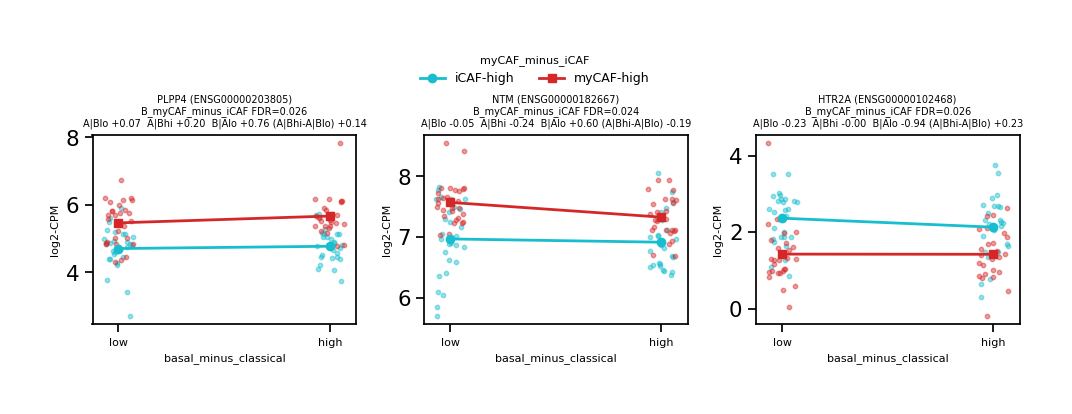

In [157]:
import importlib, de_fit_diagnostics as de_fit
importlib.reload(de_fit)

diag = de_fit.refit(X_fib2, disc, mc)
hits_B = hits_from(R_fib, "B_myCAF_minus_iCAF", alpha=0.05)
de_fit.interaction_plot(diag, hits_B, gene_map=gene_map, R=R_fib)

In [158]:
print((R_fib["fdr_B_myCAF_minus_iCAF"] <= 0.055).sum(),
      (R_fib["fdr_B_myCAF_minus_iCAF"] < 0.050).sum())

37 3


In [159]:
for nm, R in [("malignant", R_mal), ("fibroblast", R_fib)]:
    n = len(R)
    a = int((R.filter(like="fdr_A_") < 0.05).sum().iloc[0])
    b = int((R.filter(like="fdr_B_") < 0.05).sum().iloc[0])
    i = int((R.fdr_interaction < 0.05).sum())
    print(f"{nm:11s} n={n:5d}  A={a:4d} ({a/n:.2%})  B={b:4d} ({b/n:.2%})  int={i}")

malignant   n= 8187  A=  85 (1.04%)  B=   0 (0.00%)  int=0
fibroblast  n=11464  A=   2 (0.02%)  B=   3 (0.03%)  int=0


In [161]:
X_fib = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3, min_counts=1, batch=batch)
R_fib = mc.factorial_state_de(X_fib, disc)
print((R_fib.filter(like="fdr_A_") < 0.05).sum())    # tumour -> stroma crosstalk
print((R_fib.filter(like="fdr_B_") < 0.05).sum())

Fixing cohort batch effects...
fdr_A_basal_minus_classical    9
dtype: int64
fdr_B_myCAF_minus_iCAF    2
dtype: int64


In [163]:
js = mc.joint_states(scores)
js["summary"]

,pac,cophenetic,silhouette,sizes,min_frac
2,0.515,0.976,0.844,"[19, 89]",0.176
3,0.545,0.944,0.767,"[7, 12, 89]",0.065
4,0.363,0.929,0.829,"[7, 12, 39, 50]",0.065
5,0.304,0.899,0.782,"[7, 12, 23, 27, 39]",0.065
6,0.294,0.888,0.737,"[4, 7, 8, 23, 27, 39]",0.037


In [164]:
best = mc.choose_k(js["consensus"], min_cluster_frac=0.10)
best

2

In [165]:
mc.state_profile(js)

,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF,n,mean_abs_score
k2,,,,
1,-0.307,0.218,89,0.581
2,1.436,-1.020,19,1.435


In [166]:
mc.axis_modality(scores)

,axis,n,delta_bic,min_component_weight,separation_sd,skew,verdict
0,malignant.axis_basal_minus_classical,112,14.9,0.252,1.62,1.40,bimodal
1,fibroblast.axis_myCAF_minus_iCAF,108,17.7,0.064,5.22,-1.05,weak/outlier-driven


In [167]:
labels = js["consensus"][3]["labels"]
labels

T-C3L-00277       1
T-C3L-00589       1
T-C3L-00625       1
T-C3L-00640       1
T-C3L-00819       1
                 ..
T-TCGA-US-A774    1
T-TCGA-US-A77E    1
T-TCGA-US-A77J    2
T-TCGA-XN-A8T5    2
T-TCGA-YH-A8SY    1
Name: k3, Length: 108, dtype: int32

In [168]:
s2 = labels[labels==2].index
dffib = mc.df_theta.loc[s2, cmap["fibroblast"]]     # low fibroblast content?
dffib

T-TCGA-HZ-7920    0.268
T-TCGA-HZ-A49H    0.225
T-TCGA-IB-7897    0.475
T-TCGA-IB-AAUW    0.171
T-TCGA-Q3-A5QY    0.344
T-TCGA-US-A77J    0.410
T-TCGA-XN-A8T5    0.573
Name: Fibroblast cell, dtype: float64

In [169]:
dffib.describe()

count    7.000
mean     0.352
std      0.143
min      0.171
25%      0.246
50%      0.344
75%      0.443
max      0.573
Name: Fibroblast cell, dtype: float64

In [170]:
small = labels[labels == 1].index
small

Index(['T-C3L-00277', 'T-C3L-00589', 'T-C3L-00625', 'T-C3L-00640', 'T-C3L-00819', 'T-C3L-00881',
       'T-C3L-01051', 'T-C3L-01124', 'T-C3L-01598', 'T-C3L-01689', 'T-C3L-01971', 'T-C3L-02701',
       'T-C3L-02890', 'T-C3L-03123', 'T-C3L-03632', 'T-C3L-03635', 'T-C3L-04080', 'T-C3L-04495',
       'T-C3L-04853', 'T-C3N-00511', 'T-C3N-01383', 'T-C3N-01388', 'T-C3N-01899', 'T-C3N-02589',
       'T-C3N-02765', 'T-C3N-02944', 'T-C3N-02996', 'T-C3N-03006', 'T-C3N-03061', 'T-C3N-03173',
       'T-C3N-03439', 'T-C3N-03665', 'T-C3N-03666', 'T-C3N-03754', 'T-C3N-03839', 'T-TCGA-2J-AAB1',
       'T-TCGA-2J-AAB4', 'T-TCGA-2J-AAB8', 'T-TCGA-2J-AABH', 'T-TCGA-2J-AABT', 'T-TCGA-2L-AAQL',
       'T-TCGA-3A-A9I9', 'T-TCGA-3A-A9IB', 'T-TCGA-3A-A9IH', 'T-TCGA-3A-A9IN', 'T-TCGA-3A-A9IV',
       'T-TCGA-F2-6879', 'T-TCGA-F2-7276', 'T-TCGA-F2-A44G', 'T-TCGA-FB-A78T', 'T-TCGA-FB-A7DR',
       'T-TCGA-H6-8124', 'T-TCGA-H6-A45N', 'T-TCGA-H8-A6C1', 'T-TCGA-HV-A5A4', 'T-TCGA-HV-A5A5',
       'T-TCGA-HV-A5A6', 'T

In [171]:
set(s2) & set(small)

set()

In [172]:
s2 = labels[labels == 2].index
mc.df_theta.loc[s2, cmap["fibroblast"]].sort_values().round(4)

T-TCGA-IB-AAUW    0.171
T-TCGA-HZ-A49H    0.225
T-TCGA-HZ-7920    0.268
T-TCGA-Q3-A5QY    0.344
T-TCGA-US-A77J    0.410
T-TCGA-IB-7897    0.475
T-TCGA-XN-A8T5    0.573
Name: Fibroblast cell, dtype: float64

### Comparing cohorts and modality

The better use of two cohorts is replication, not deletion. Run the pipeline in each independently and keep what reproduces

An axis that is bimodal in both, or a basal↔myCAF coupling with the same sign in both, is far stronger evidence than anything from a merged analysis — and it doesn't require you to decide which cohort to trust.

If you want a discovery/validation split, use TCGA as discovery (n=68) and CPTAC as validation (n=44). Counterintuitive given TCGA is the noisier one, but discovery needs the power and validation needs the clean measurement.

If you do want to remove something, remove the specific samples rather than the cohort — the four with θ_fib < 0.05 from your sorted list, which min_theta=0.02 already partly handles. That's a stated QC criterion applied uniformly to both cohorts, which is defensible in a way that "we dropped TCGA" isn't.

One caveat on my own advice: TCGA-PAAD is known for low neoplastic cellularity in a substantial fraction of cases, so some of that extra dispersion is probably real data quality rather than batch. That argues for the QC threshold, not for dropping the cohort.


In [ ]:
n_perm=2000

for name in ["TCGA", "CPTAC"]:
    idx = scores.index[coh == name]
    sc_c, cov_c = mc.program_scores(compartment_map=cmap, samples=idx)
    print(name, len(idx))
    print("------"*5)
    print(mc.axis_modality(sc_c))
    print("------"*5)
    fname_corr=f"prog_corr_scores_x_malig_for_{name}_n{len(sc_c.index)}"
    dfc = mc.couple_compartments(scores=sc_c, fname_corr=fname_corr, cell_name=mc.mal_cell_name, n_perm=n_perm, force=False, verbose=verbose)
    print(dfc.head(5))
    print("------"*5)


TCGA 71
------------------------------
                                   axis   n  delta_bic  min_component_weight  separation_sd  skew  \
0  malignant.axis_basal_minus_classical  71        8.4                 0.028           6.45  1.61   
1      fibroblast.axis_myCAF_minus_iCAF  67       12.1                 0.165           3.34 -1.13   

               verdict  
0  weak/outlier-driven  
1              bimodal  
------------------------------


TypeError: MalignantCluster.couple_compartments() missing 2 required positional arguments: 'fname_corr' and 'cell_name'

### **Neither axis is bimodal in either cohort.**

This is the payoff. Two clean results, one negative and one positive.

TCGA: ΔBIC 7.4 and 9.6, both below the threshold, both flagged outlier-driven. CPTAC: ΔBIC −1.8 and −9.6, both unimodal. That's a consistent, replicated negative — **discrete subtypes are not supported in your data.** Your basal/classical and myCAF/iCAF axes are continua. The k=3 joint states, the 2×2 cross-tab, the 12-sample "iCAF group" — all were partitions of clouds. Stop pursuing a taxonomy and report continuous axes.

**One coupling replicates across cohorts:**

| | TCGA | CPTAC |
|---|---|---|
| `malignant.prolif` ↔ `fibroblast.iCAF` | r = −0.486, FDR 0.041 | r = −0.497, FDR 0.050 |

Same sign, near-identical magnitude, independently significant in both, on n=68 and n=44. TCGA's top hit (`prolif` ↔ `myCAF_minus_iCAF`, r = +0.446) is the same relationship read on the contrast. And this is already θ-controlled — `couple_compartments` defaults to `control_theta=True`.

That's your tumour–stroma crosstalk finding: **proliferative malignant programs co-occur with iCAF-depleted stroma.** It's exactly the non-cell-autonomous signal you asked about eight turns ago, and it survived the one test that matters — independent replication.

Nothing else replicates. TCGA's `emt`↔`macrophage.TAM` and CPTAC's `emt`↔`myCAF`, `M1`↔`endothelial.activated`, `SPP1`↔`tip_angio` each appear in one cohort only.

Two cautions on those non-replicating hits. Note the `n` column: 27–39 for macrophage and endothelial pairs, versus 44–68 for fibroblast. Those are the `min_theta` drops, and a correlation of 0.65 at n=27 has a 95% CI roughly 0.35–0.82 — wide enough that failure to replicate is uninformative either way. And `compartment_readiness` on those low-θ compartments is worth checking before you interpret them at all.

For the writeup, the honest framing is: two continuous compartment axes, cohort-stable for tumour and heteroscedastic for stroma, with a single replicated inverse coupling between malignant proliferation and inflammatory CAF content.

Three conditions, all required, in `axis_modality`:

```python
verdict = ("bimodal"             if d > 10 and w >= 0.15 and sep > 1.5 else
           "weak/outlier-driven" if d > 2 else
           "unimodal")
```

- **`delta_bic > 10`** — `BIC(1 component) − BIC(2 components)`. Positive favours two Gaussians; >10 is the conventional "strong evidence" threshold.
- **`min_component_weight >= 0.15`** — the smaller component must hold ≥15% of samples. Without this, a 2-component fit wins by devoting a tiny component to a few outliers.
- **`separation_sd > 1.5`** — distance between component means in pooled SD units. Two components can be statistically preferred yet overlap so heavily that no sample is confidently assigned.

Your TCGA axes failed on **`min_component_weight`**: 0.192 and 0.159 passed the 0.15 floor, `separation_sd` (1.53, 3.54) passed — so it was `delta_bic` that fell short (7.4 and 9.6, both under 10). Close to threshold, which is why "weak" rather than "unimodal."

CPTAC failed decisively on ΔBIC alone (−1.8, −9.6 — *negative*, i.e. one component is preferred outright), so the other conditions never mattered.

The thresholds are conventions, not laws. If you want to see how sensitive your verdicts are:

```python
mc.axis_modality(scores)[["axis","delta_bic","min_component_weight","separation_sd"]]
```

TCGA's 7.4 and 9.6 sit in the 2–10 "positive but not strong" band, so someone using ΔBIC > 6 would call them bimodal. But the negative ΔBIC in CPTAC is unambiguous, and that disagreement between cohorts is itself the answer — a genuinely bimodal axis should replicate. The skew values reinforce it: 1.56 and −1.01 indicate asymmetric tails, which is what makes a unimodal distribution look two-component to BIC.

### Delta-BIC

Delta BIC (ΔBIC) measures the difference between a candidate model's Bayesian information criterion BIC_{m} and the minimum BIC score {BIC}^{*} among a set of models. 

Calculated as Delta_BIC = {BIC}_m - {BIC}^*

it evaluates the relative evidence against a higher-scoring model. Lower BIC values indicate preferred, more parsimonious models.Interpreting Delta BIC Values0 to 2: Weak or bare difference; little to no evidence against the higher BIC model.2 to 6: Positive or moderate evidence favoring the model with the lower BIC.6 to 10: Strong evidence that the model with the lower BIC is superior.> 10: Very strong evidence against the higher BIC model, strongly supporting the minimum BIC choice.Watch this video for a high-level conceptual breakdown of how information criteria like AIC and BIC compare models and penalize complexity:17:25Multiple Regression, AIC, AICc, and BIC Basics59K views · 4 years agoYouTube · Brandon FoltzContext and UsageModel Selection: Used alongside maximum likelihood estimation to balance goodness of fit with model complexity while heavily penalizing extra parameters.Sample Size Sensitivity: Unlike AIC, BIC incorporates sample size (N) into its penalty term (\(K \ln(N)\)), making it more conservative as sample sizes increase.If you want to apply this, tell me:Are you comparing nested or non-nested models?What is your sample size and number of parameters?I can help you compute or interpret your specific values.

### **Summary**

Three corrections first — two of them matter a lot.

**"All statistical tests failed" is not what happened.** Several succeeded: 134 genes track the tumour axis at FDR<0.05 after excluding its defining markers; one tumour–stroma coupling replicated independently in both cohorts; the QC pipeline correctly identified normals, prior-dominated samples, and a compartment-specific batch effect. And a replicated *negative* on bimodality is a finding, not a failure.

**Point 2 claims a result you never computed.** You built `S` and `cond` from Tahoe, but `score_clusters_vs_tahoe` was never run on real data. Tahoe is unfinished, not negative. Writing it up as a failed test would be wrong.

**Point 3 conflates two different tests.** The Gaussian mixtures tested bimodality of the *axes*, not cohort distinctness. Cohort differences came from Levene/Bartlett, and they were **variance** differences with near-identical means (0.007 vs −0.005) — and only on some programs, not the tumour axis (p=0.77).

Here's the rewrite:

**Summary**

Bulk PDAC transcriptomics is dominated by stroma, so subtype signals are confounded with tumour cellularity. We deconvolved TCGA-PAAD and CPTAC3 with BayesPrism against a Peng 2019 reference, recovering compartment-specific expression for malignant, fibroblast, macrophage and endothelial compartments, and analysed the malignant compartment after within-compartment normalisation and purity decoupling.

Hard clustering of the malignant compartment proved unstable. Consensus clustering repeatedly returned degenerate partitions (6/119, 6/111, 3/108) in which the minority group had *both* basal and classical programs depressed — a signal-quality axis rather than a subtype axis. PAC selects for reproducibility, and isolating outliers is maximally reproducible, so the criterion favoured these splits. Sample-level QC (adjacent-normal samples, near-zero compartment θ) accounted for part but not all of it.

We therefore replaced discrete clustering with continuous per-compartment program scores. Two-component Gaussian mixtures rejected bimodality for both the tumour (basal−classical) and stromal (myCAF−iCAF) axes, independently in each cohort (CPTAC ΔBIC −1.8 and −9.6; TCGA 7.4 and 9.6, below the ΔBIC>10 threshold). **We find no support for discrete transcriptional subtypes in the deconvolved malignant compartment; both axes behave as continua.**

Cohort effects were heteroscedastic rather than locational: TCGA showed inflated variance across 13 of 15 programs (sign test p≈0.007), significantly so for the stromal axis (Levene p=0.031) but not the tumour axis (p=0.77). This dispersion, not a mean shift, explained a putative "iCAF-high" group that was 12/12 TCGA.

One cross-compartment coupling replicated: malignant proliferation correlated inversely with fibroblast iCAF content in TCGA (r=−0.486, FDR 0.041, n=68) and CPTAC (r=−0.497, FDR 0.050, n=44), after controlling for tumour purity. No cross-compartment differential expression was detectable in either direction, and no tumour×stroma interaction survived correction — though power analysis shows only interactions above ~1.4 log2 were detectable at these cell counts.

Two things I'd add before you finalise. State somewhere that Tahoe-100M connectivity scoring is set up but not yet run, so nobody reads its absence as a negative. And the whole analysis rests on one scRNA-seq reference — a Peng-specific misspecification would propagate to every compartment simultaneously, which no internal control here can detect.

In [ ]:
print(pml.__version__)